# Check the allee effect derived from the predator-prey model with simulations

Prey-only equilibria:
  x = 0.00, x = 15.00, x = 25.00

Interpretation:
  Since a = 15.00, initial prey densities below a tend to extinction.


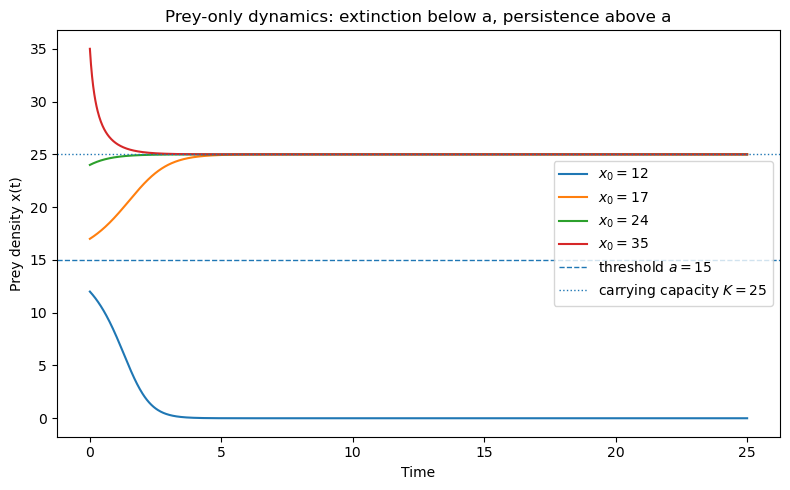

In [14]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Parameters chosen so that a < delta/gamma < K, hence a positive coexistence equilibrium exists.
alpha = 2.2 #1.2
beta =0.08  #0.04
gamma = 0.06  #0.05
delta = 0.8 #0.6
a = 15 #10.0
K = 25 #30.0


def prey_only_rhs(t: float, x: np.ndarray) -> np.ndarray:
    """Right-hand side for prey-only dynamics."""
    return alpha * x * (1.0 - x / K) * (x / a - 1.0)


def prey_equilibria() -> tuple[float, float, float]:
    return 0.0, a, K


def simulate_prey_only() -> None:
    """Plot prey-only trajectories for initial data below and above the threshold a."""
    t_eval = np.linspace(0.0, 25.0, 1200)
    initial_conditions = [12, 17, 24, 35]

    plt.figure(figsize=(8, 5))
    for x0 in initial_conditions:
        sol = solve_ivp(
            lambda t, x: prey_only_rhs(t, x),
            (t_eval[0], t_eval[-1]),
            [x0],
            t_eval=t_eval,
            rtol=1e-8,
            atol=1e-10,
        )
        plt.plot(sol.t, sol.y[0], label=fr"$x_0={x0}$")

    plt.axhline(a, linestyle="--", linewidth=1.0, label=fr"threshold $a={a}$")
    plt.axhline(K, linestyle=":", linewidth=1.0, label=fr"carrying capacity $K={K}$")
    plt.xlabel("Time")
    plt.ylabel("Prey density x(t)")
    plt.title("Prey-only dynamics: extinction below a, persistence above a")
    plt.legend()
    plt.tight_layout()
    plt.savefig("prey_only_allee2.png", dpi=300)  


def main() -> None:
    x0_eq, xa_eq, xk_eq = prey_equilibria()
   # x_star, y_star = coexistence_equilibrium()

    print("Prey-only equilibria:")
    print(f"  x = {x0_eq:.2f}, x = {xa_eq:.2f}, x = {xk_eq:.2f}")
    print("\nInterpretation:")
    print(f"  Since a = {a:.2f}, initial prey densities below a tend to extinction.")
   # print(f"  Since delta/gamma = {delta/gamma:.2f} lies between a and K, coexistence is possible.")

    simulate_prey_only()

    
    

if __name__ == "__main__":
    main()
